In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['CUDA_VISIBLE_DEVICES'] = "0"

import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
import keras
from keras import layers
from tensorflow.keras.layers import Layer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, LSTM, Bidirectional, TimeDistributed
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import pandas as pd

In [2]:
import RNN_preprocessing_new as rp 

In [3]:
X1 = rp.X1
y1 = rp.y1
X2 = rp.X2
y2 = rp.y2
X1_seq_test = rp.X1_seq_test
X2_seq_test = rp.X2_seq_test
y1_seq_test = rp.y1_seq_test 

In [4]:
# Clear memory associated with the module
import sys
del rp
if 'RNN_preprocessing_new' in sys.modules:
    del sys.modules['RNN_preprocessing_new']

# Clear memory from global variables if needed
import gc
gc.collect()

6

In [5]:
X1_train, X1_val, y1_train, y1_val = train_test_split(X1, y1, test_size=0.2, random_state=0)

In [39]:
X2_train, X2_val, y2_train, y2_val = train_test_split(X2, y2, test_size=0.2, random_state=0)

LSTM

In [6]:
class Attention(Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)

    def call(self, inputs):
        """
        Applies attention mechanism to the inputs.

        Args:
            inputs: Tensor of shape (batch_size, seq_length, features).

        Returns:
            Tensor of shape (batch_size, features).
        """
        query = inputs  # Use the same input as query, key, and value
        key = inputs
        value = inputs

        # Compute attention scores
        scores = tf.matmul(query, key, transpose_b=True)  # Shape: (batch, seq_length, seq_length)
        scores = tf.nn.softmax(scores, axis=-1)  # Normalize scores

        # Weighted sum of the values
        context = tf.matmul(scores, value)  # Shape: (batch, seq_length, features)

        return context


In [7]:
def build_bilstm_with_attention(input_shape, num_classes):
    """
    Builds a BiLSTM model with an attention mechanism.

    Args:
        input_shape (tuple): Shape of the input data (seq_length, num_features).
        num_classes (int): Number of output classes.

    Returns:
        keras.Model: Compiled BiLSTM model with attention.
    """
    inputs = Input(shape=input_shape)
    x = Bidirectional(LSTM(64, return_sequences=True))(inputs)
    x = Attention()(x)  # Add attention mechanism
    x = TimeDistributed(Dense(64, activation="relu"))(x)
    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs)
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

In [8]:
seq_length = 10

In [9]:
#Model for the BiPo 214 chain
model1 = build_bilstm_with_attention((seq_length, X1_train.shape[2]), y1_train.shape[2])

model1.summary()

2025-01-28 16:06:30.997304: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 10, 6)]           0         
                                                                 
 bidirectional (Bidirection  (None, 10, 128)           36352     
 al)                                                             
                                                                 
 attention (Attention)       (None, 10, 128)           0         
                                                                 
 time_distributed (TimeDist  (None, 10, 64)            8256      
 ributed)                                                        
                                                                 
 dense_1 (Dense)             (None, 10, 4)             260       
                                                                 
Total params: 44868 (175.27 KB)
Trainable params: 44868 (175.

In [40]:
#Model for the BiPo 212 chain
model2 = build_bilstm_with_attention((seq_length, X2_train.shape[2]), y2_train.shape[2])
model2.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 10, 6)]           0         
                                                                 
 bidirectional (Bidirection  (None, 10, 128)           36352     
 al)                                                             
                                                                 
 attention (Attention)       (None, 10, 128)           0         
                                                                 
 time_distributed (TimeDist  (None, 10, 64)            8256      
 ributed)                                                        
                                                                 
 dense_1 (Dense)             (None, 10, 6)             390       
                                                                 
Total params: 44998 (175.77 KB)
Trainable params: 44998 (175.

In [10]:
#callback for reducing the learning rate and stopping early in case the loss function hits a plateau
callbacks = [
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4, verbose=1, min_lr=1E-6),
    tf.keras.callbacks.EarlyStopping(patience=10, verbose=1, baseline=None, restore_best_weights=True)
]

In [11]:
# Clear any previous session
tf.keras.backend.clear_session()
gc.collect()


6184

In [13]:
y1_train.shape

(1611564, 10, 4)

In [43]:
rp.y1_seq_train.shape

(3457560, 10, 4)

In [12]:
# Train model 1
history1 = model1.fit(X1_train, y1_train, epochs=200, batch_size=256, verbose=2,
                      validation_data=(X1_val, y1_val),
                      callbacks=callbacks)

Epoch 1/200
6296/6296 - 361s - loss: 0.3133 - accuracy: 0.8750 - val_loss: 0.1903 - val_accuracy: 0.9288 - lr: 0.0010 - 361s/epoch - 57ms/step
Epoch 2/200
6296/6296 - 349s - loss: 0.1781 - accuracy: 0.9329 - val_loss: 0.1707 - val_accuracy: 0.9349 - lr: 0.0010 - 349s/epoch - 56ms/step
Epoch 3/200
6296/6296 - 338s - loss: 0.1672 - accuracy: 0.9364 - val_loss: 0.1651 - val_accuracy: 0.9367 - lr: 0.0010 - 338s/epoch - 54ms/step
Epoch 4/200
6296/6296 - 341s - loss: 0.1628 - accuracy: 0.9378 - val_loss: 0.1646 - val_accuracy: 0.9374 - lr: 0.0010 - 341s/epoch - 54ms/step
Epoch 5/200
6296/6296 - 310s - loss: 0.1597 - accuracy: 0.9388 - val_loss: 0.1591 - val_accuracy: 0.9390 - lr: 0.0010 - 310s/epoch - 49ms/step
Epoch 6/200
6296/6296 - 240s - loss: 0.1581 - accuracy: 0.9393 - val_loss: 0.1573 - val_accuracy: 0.9396 - lr: 0.0010 - 240s/epoch - 38ms/step
Epoch 7/200
6296/6296 - 240s - loss: 0.1573 - accuracy: 0.9396 - val_loss: 0.1581 - val_accuracy: 0.9392 - lr: 0.0010 - 240s/epoch - 38ms/step

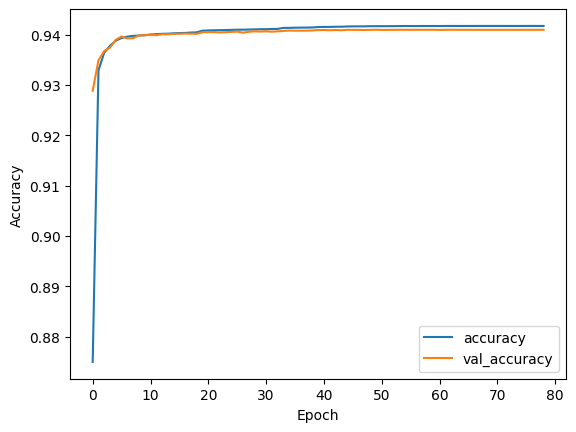

In [13]:
#plotting the accuracy of the first model
plt.plot(history1.history['accuracy'], label='accuracy')
plt.plot(history1.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

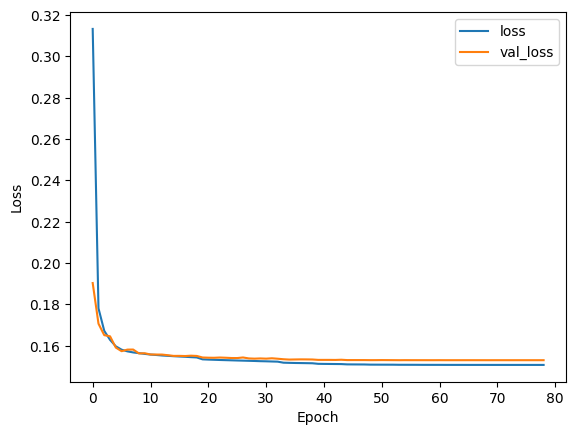

In [14]:
#plotting the loss over epoch for the first model
plt.plot(history1.history['loss'], label='loss')
plt.plot(history1.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

In [15]:
# Predict the labels for the test set
y_pred1 = model1.predict(X1_seq_test)

27013/27013 [==============================] - 124s 5ms/step


In [16]:
#convert predictions to class labels
y_pred_classes1 = np.argmax(y_pred1, axis=2)

# Convert one-hot encoded true labels back to class labels
y_test_classes1 = np.argmax(y1_seq_test, axis=2)

In [17]:
# Reshape or flatten the arrays
y_test_classes1_flat = y_test_classes1.reshape(-1)  # Flatten y_test_classes1
y_pred_classes1_flat = y_pred_classes1.reshape(-1)  # Flatten y_pred_classes1

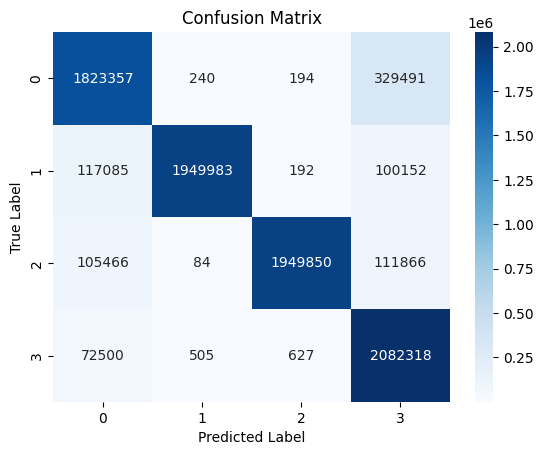

In [18]:
# Compute the confusion matrix
conf_matrix1 = confusion_matrix(y_test_classes1_flat, y_pred_classes1_flat)

# Plot the confusion matrix
sns.heatmap(conf_matrix1, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [19]:
# Calculate metrics
precision_macro = precision_score(y_test_classes1_flat, y_pred_classes1_flat, average='macro')
recall_macro = recall_score(y_test_classes1_flat, y_pred_classes1_flat, average='macro')
f1_macro = f1_score(y_test_classes1_flat, y_pred_classes1_flat, average='macro')

precision_micro = precision_score(y_test_classes1_flat, y_pred_classes1_flat, average='micro')
recall_micro = recall_score(y_test_classes1_flat, y_pred_classes1_flat, average='micro')
f1_micro = f1_score(y_test_classes1_flat, y_pred_classes1_flat, average='micro')

precision_weighted = precision_score(y_test_classes1_flat, y_pred_classes1_flat, average='weighted')
recall_weighted = recall_score(y_test_classes1_flat, y_pred_classes1_flat, average='weighted')
f1_weighted = f1_score(y_test_classes1_flat, y_pred_classes1_flat, average='weighted')

# Create a summary table for F1, Recall, and Precision
metrics_summary = pd.DataFrame({
    'Metric': [
        'Precision (Macro)', 'Recall (Macro)', 'F1 Score (Macro)',
        'Precision (Micro)', 'Recall (Micro)', 'F1 Score (Micro)',
        'Precision (Weighted)', 'Recall (Weighted)', 'F1 Score (Weighted)'
    ],
    'Score': [
        precision_macro, recall_macro, f1_macro,
        precision_micro, recall_micro, f1_micro,
        precision_weighted, recall_weighted, f1_weighted
    ]
})

# Display the table
print(metrics_summary)

                 Metric     Score
0     Precision (Macro)  0.913349
1        Recall (Macro)  0.902998
2      F1 Score (Macro)  0.904739
3     Precision (Micro)  0.903007
4        Recall (Micro)  0.903007
5      F1 Score (Micro)  0.903007
6  Precision (Weighted)  0.913592
7     Recall (Weighted)  0.903007
8   F1 Score (Weighted)  0.904867


In [20]:
accuracy = accuracy_score(y_test_classes1_flat, y_pred_classes1_flat)
print({f"Accuracy:{accuracy}"})

{'Accuracy:0.9030066254738885'}


In [21]:
#save the first trained model
model1.save('model_bidirec_lstm_214.h5')

/home/pipc06/.local/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [36]:
def signal_detection_metrics(test_classes, pred_classes, signal_classes):
    """
    Calculate the following metrics for each specified class:
    1) Percentage of actual signal events detected w.r.t total signal events.
    2) Percentage of actual signal detected w.r.t. the predicted signal events.

    Parameters:
    - test_classes: Array-like, ground truth labels
    - pred_classes: Array-like, predicted labels
    - signal_classes: int or list, class/classes for which the metrics should be computed

    Returns:
    - A dictionary containing results for each class.
    """
    
    # Ensure signal_classes is a list
    if isinstance(signal_classes, int):
        signal_classes = [signal_classes]
    
    # Convert to NumPy arrays for easier computation
    test_classes = np.array(test_classes)
    pred_classes = np.array(pred_classes)

    results = {}

    for cls in signal_classes:
        # True Positives (TP): cases where both test and pred match the class
        tp = np.sum((test_classes == cls) & (pred_classes == cls))
        
        # Total actual signal events for the class
        total_signal_events = np.sum(test_classes == cls)
        
        # Total predicted signal events for the class
        total_predicted_signal = np.sum(pred_classes == cls)
        
        # Compute percentages
        percentage_actual_signal_detected = (tp / total_signal_events * 100) if total_signal_events > 0 else 0
        percentage_detected_signal_accuracy = (tp / total_predicted_signal * 100) if total_predicted_signal > 0 else 0

        results[cls] = {
            "Percentage of actual signal events detected": percentage_actual_signal_detected,
            "Percentage of detected signal accuracy": percentage_detected_signal_accuracy
        }
    
    # Print results
    for cls, metrics in results.items():
        print(f"\nResults for class {cls}:")
        print(f"  - Percentage of actual signal events detected: {metrics['Percentage of actual signal events detected']:.2f}%")
        print(f"  - Percentage of detected signal accuracy: {metrics['Percentage of detected signal accuracy']:.2f}%")

    return results

In [37]:
result = signal_detection_metrics(y_test_classes1_flat, y_pred_classes1_flat, [1, 2])
print(result)


Results for class 1:
  - Percentage of actual signal events detected: 89.97%
  - Percentage of detected signal accuracy: 99.96%

Results for class 2:
  - Percentage of actual signal events detected: 89.97%
  - Percentage of detected signal accuracy: 99.95%
{1: {'Percentage of actual signal events detected': 89.96826630100784, 'Percentage of detected signal accuracy': 99.95750487489312}, 2: {'Percentage of actual signal events detected': 89.96819033750356, 'Percentage of detected signal accuracy': 99.94807426251869}}


In [ ]:
# Train model 2
history2 = model2.fit(X2_train, y2_train, epochs=200, batch_size=256, verbose=2,
                      validation_data=(X2_val, y2_val),
                      callbacks=callbacks)

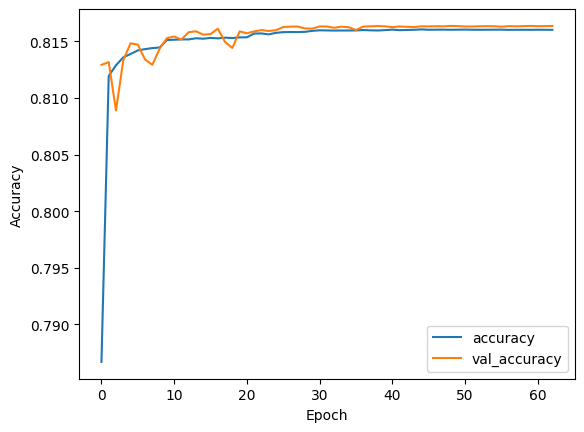

In [7]:
#plotting the accuracy of the second model
plt.plot(history2.history['accuracy'], label='accuracy')
plt.plot(history2.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

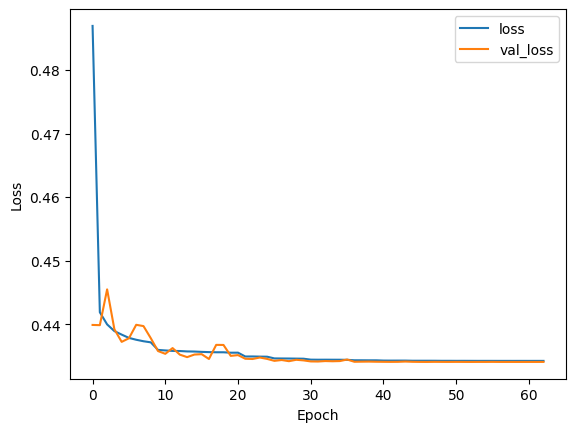

In [8]:
#plotting the loss over epoch for the second model
plt.plot(history2.history['loss'], label='loss')
plt.plot(history2.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

In [9]:
# Generate sequences of the test data of the second chain
X2_test_seq, y2_test_seq = rp.create_sequences(rp.fes.X2_test, rp.fes.y2_test, rp.seq_length)
# Predict the labels for the test set
y_pred2 = model2.predict(X2_test_seq)

#convert predictions to class labels
y_pred_classes2 = np.argmax(y_pred2, axis=1)

# Convert one-hot encoded true labels back to class labels
y_test_classes2 = np.argmax(y2_test_seq, axis=1)

53464/53464 [==============================] - 259s 5ms/step


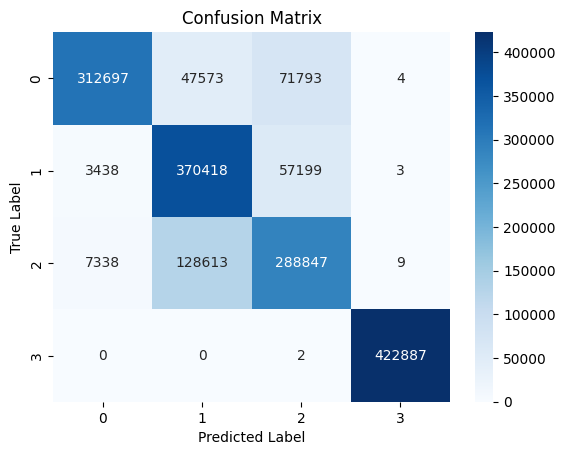

In [10]:
#plotting confusion matrix for the second model
conf_matrix2 = confusion_matrix(y_test_classes2, y_pred_classes2)
sns.heatmap(conf_matrix2, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [11]:
# Calculate metrics
precision_macro = precision_score(y_test_classes2, y_pred_classes2, average='macro')
recall_macro = recall_score(y_test_classes2, y_pred_classes2, average='macro')
f1_macro = f1_score(y_test_classes2, y_pred_classes2, average='macro')

precision_micro = precision_score(y_test_classes2, y_pred_classes2, average='micro')
recall_micro = recall_score(y_test_classes2, y_pred_classes2, average='micro')
f1_micro = f1_score(y_test_classes2, y_pred_classes2, average='micro')

precision_weighted = precision_score(y_test_classes2, y_pred_classes2, average='weighted')
recall_weighted = recall_score(y_test_classes2, y_pred_classes2, average='weighted')
f1_weighted = f1_score(y_test_classes2, y_pred_classes2, average='weighted')

# Create a summary table for F1, Recall, and Precision
metrics_summary = pd.DataFrame({
    'Metric': [
        'Precision (Macro)', 'Recall (Macro)', 'F1 Score (Macro)',
        'Precision (Micro)', 'Recall (Micro)', 'F1 Score (Micro)',
        'Precision (Weighted)', 'Recall (Weighted)', 'F1 Score (Weighted)'
    ],
    'Score': [
        precision_macro, recall_macro, f1_macro,
        precision_micro, recall_micro, f1_micro,
        precision_weighted, recall_weighted, f1_weighted
    ]
})

# Display the table
print(metrics_summary)

                 Metric     Score
0     Precision (Macro)  0.833901
1        Recall (Macro)  0.815748
2      F1 Score (Macro)  0.817764
3     Precision (Micro)  0.815310
4        Recall (Micro)  0.815310
5      F1 Score (Micro)  0.815310
6  Precision (Weighted)  0.833708
7     Recall (Weighted)  0.815310
8   F1 Score (Weighted)  0.817383


In [12]:
#save the second trained model
model2.save('model_bidirec_lstm_212.h5')

/home/pipc06/.local/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


: 

In [ ]:
result_2 = signal_detection_metrics(y_test_classes2_flat, y_pred_classes2_flat, [1, 2])
print(result_2)